In [31]:
# pip install astroquery astropy matplotlib
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
import astropy.units as u
import numpy as np
import os
import matplotlib.pyplot as plt


def fetch_plot_and_stitch_hst(
    coord,                      # SkyCoord or "hh:mm:ss ±dd:mm:ss" or (ra_deg, dec_deg)
    radius_arcsec=1.0,
    include_stis=True,
    include_cos=True,
    gratings=None,              # e.g. ["G230L","G140L","G130M"]; applies to both STIS and COS; None = all
    stis_include_medium_high=False,  # False to keep only STIS low-res G..L gratings
    cos_use_x1dsum=True,        # True => prefer COS *x1dsum* (coadded) if available
    download_dir="hst_uv_dl",
    max_products=None,          # int or None
    grid_dw=None,               # wavelength bin size for stitching [Å]; None = auto from data
    legend=True,
    save_basename=None          # filename stem (no extension); None -> position-based name
):
    """
    Query MAST for HST STIS and/or COS 1-D spectra near coord, download, plot, and stitch all segments
    onto a single wavelength grid with inverse-variance weighting. Overlaps are averaged; gaps are NaN.

    Output FITS:
      - Primary HDU: headers (OBJECT, RADIUS, DW, NSEG)
      - 'SPECTRUM' (BinTable): wavelength [Å], flux [erg s^-1 cm^-2 Å^-1], ivar [1/(flux_unit^2)]
      - 'SEGMENTS' (BinTable): instrument, grating, segment, wmin, wmax, filename

    Returns
    -------
    out_fits : str or None
        Path to stitched FITS (None if nothing found).
    files : list[str]
        Local paths to downloaded 1-D files used.
    """

    # --- normalize coordinate input ---
    if isinstance(coord, SkyCoord):
        sc = coord
    elif isinstance(coord, str):
        sc = SkyCoord(coord)
    else:
        ra_deg, dec_deg = coord
        sc = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg)

    radius = (radius_arcsec * u.arcsec)

    inst_list = []
    if include_stis:
        inst_list += ["STIS/CCD", "STIS/NUV-MAMA", "STIS/FUV-MAMA"]
    if include_cos:
        inst_list += ["COS/NUV", "COS/FUV"]
    if not inst_list:
        print("Both include_stis and include_cos are False; nothing to do.")
        return None, []

    # --- search observations ---
    obs = Observations.query_criteria(
        coordinates=sc,
        radius=radius,
        obs_collection="HST",
        instrument_name=inst_list,
        dataproduct_type="spectrum",
    )
    if len(obs) == 0:
        print("No HST spectroscopic observations (STIS/COS) found near that position.")
        return None, []

    # optional grating filter (CAOM 'filters' often holds optical element name)
    if gratings:
        gratings = [g.upper() for g in gratings]
        keep = np.zeros(len(obs), dtype=bool)
        for i, f in enumerate(obs["filters"]):
            s = "" if f is None else str(f).upper()
            if any(g in s for g in gratings):
                keep[i] = True
        obs = obs[keep]
        if len(obs) == 0:
            print("No HST spectra matched the requested grating(s).")
            return None, []

    # --- get product list ---
    products = Observations.get_product_list(obs)

    # prefer COS x1dsum if requested; otherwise accept x1d; for STIS accept x1d/sx1
    wanted = []
    if include_cos and cos_use_x1dsum:
        wanted += ["X1DSUM"]    # COS: fully coadded
    if include_cos:
        wanted += ["X1D"]       # COS exposure-level (also used by STIS MAMAs)
    if include_stis:
        wanted += ["SX1"]       # STIS CCD 1-D

    one_d = Observations.filter_products(
        products,
        productSubGroupDescription=wanted,
        extension="fits"
    )
    if len(one_d) == 0:
        print("Found HST observations, but no suitable 1-D products (x1d/sx1/x1dsum).")
        return None, []

    if max_products is not None:
        one_d = one_d[:max_products]

    # --- download ---
    os.makedirs(download_dir, exist_ok=True)
    manifest = Observations.download_products(one_d, download_dir=download_dir, mrp_only=False)
    files = [row.get("Local Path") for row in manifest if row.get("Local Path")]
    if len(files) == 0:
        print("Download completed but no local files were reported.")
        return None, []

    # --- parse files into segments ---
    # segment dict: {'w','f','e','ivar','grating','segment','instr','filename'}
    segments = []
    for fp in files:
        with fits.open(fp) as hdul:
            hdr0 = hdul[0].header
            instr = (hdr0.get("INSTRUME") or "").upper()  # 'STIS' or 'COS'
            if instr not in ("STIS", "COS"):
                continue

            grating = (hdr0.get("OPT_ELEM") or "UNKNOWN").upper()
            detseg  = (hdr0.get("SEGMENT") or "").upper()  # e.g., COS FUVA/FUVB; STIS often blank

            # optional: skip medium/high for STIS
            if instr == "STIS" and not stis_include_medium_high:
                # keep only low-res GxxxL; drop Echelle and GxxxM
                if grating.startswith("E") or grating.endswith("M"):
                    continue

            # data table
            # For both STIS and COS x1d/x1dsum the first extension is usually the 1-D table
            if len(hdul) < 2 or not hasattr(hdul[1], "data") or hdul[1].data is None:
                continue
            tab = hdul[1].data

            # Some products store multiple rows (echelle orders or segments)
            for row in tab:
                # Column names are typically the same across STIS/COS 1-D
                w = np.asarray(row["WAVELENGTH"], dtype=float)
                f = np.asarray(row["FLUX"], dtype=float)
                # ERROR or ERROR_ARRAY; handle both
                e = row["ERROR"] if "ERROR" in row.array.names else row["ERROR_ARRAY"]
                e = np.asarray(e, dtype=float)
                dq = np.asarray(row["DQ"], dtype=int) if "DQ" in row.array.names else np.zeros_like(w, int)

                m = np.isfinite(w) & np.isfinite(f) & np.isfinite(e) & (e > 0) & (dq == 0)
                if not np.any(m):
                    continue
                w, f, e = w[m], f[m], e[m]
                if w.size < 5:
                    continue

                iv = 1.0 / (e * e)
                segments.append({
                    "w": w, "f": f, "e": e, "ivar": iv,
                    "grating": grating, "segment": detseg,
                    "instr": instr, "filename": os.path.basename(fp)
                })

    if len(segments) == 0:
        print("No usable spectral rows found in the downloaded files.")
        return None, files

    # --- plot by grating (colors auto) ---
    plt.figure(figsize=(10, 5))
    seen = set()
    for s in segments:
        label = f"{s['instr']}:{s['grating']}" if (s['instr'], s['grating']) not in seen else None
        plt.plot(s["w"], s["f"], lw=0.9, alpha=0.85, label=label)
        seen.add((s['instr'], s['grating']))

    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
    title = save_basename or f"{sc.to_string('hmsdms')} (r={radius_arcsec}\")"
    if gratings:
        title += f" | gratings: {', '.join(gratings)}"
    plt.title(f"HST spectra (STIS/COS) @ {title}")
    if legend:
        plt.legend(title="Instrument:Grating", fontsize=8)
    plt.tight_layout()
    plt.ylim(0, np.percentile(np.concatenate([s["f"] for s in segments]), 99.5) * 1.1)
    plt.show()

    # --- build global grid and stitch ---
    wmin = min(np.min(s["w"]) for s in segments)
    wmax = max(np.max(s["w"]) for s in segments)

    if grid_dw is None:
        med_steps = []
        for s in segments:
            d = np.diff(s["w"])
            d = d[np.isfinite(d) & (d > 0)]
            if d.size:
                med_steps.append(np.median(d))
        grid_dw = float(np.clip(np.median(med_steps), 0.05, 5.0)) if med_steps else 0.2

    grid = np.arange(wmin, wmax + 0.5 * grid_dw, grid_dw)
    num = np.zeros_like(grid)
    den = np.zeros_like(grid)

    # nearest-bin accumulation (fast; fine for low/med/high res if grid_dw sensible)
    for s in segments:
        idx = np.clip(((s["w"] - grid[0]) / grid_dw).astype(int), 0, len(grid) - 1)
        np.add.at(num, idx, s["f"] * s["ivar"])
        np.add.at(den, idx, s["ivar"])

    ok = den > 0
    flux = np.full_like(grid, np.nan, dtype=float)
    ivar = np.zeros_like(grid, dtype=float)
    flux[ok] = num[ok] / den[ok]
    ivar[ok] = den[ok]

    # --- save stitched spectrum ---
    if save_basename is None:
        target_stem = sc.to_string('hmsdms').replace(' ', '_').replace(':', '')
        save_basename = os.path.join(download_dir, f"{target_stem}_hst_stitched")

    out_fits = f"{save_basename}.fits"

    # main table
    tbl = Table(
        [grid, flux, ivar],
        names=["wavelength", "flux", "ivar"],
        meta={"COMMENT": "Stitched HST spectrum (STIS/COS); IVAR-weighted in overlaps; gaps are NaN"}
    )
    hdu_main = fits.BinTableHDU(tbl, name="SPECTRUM")

    # metadata for segments
    seg_rows = []
    for s in segments:
        seg_rows.append((
            s["instr"], s["grating"], s["segment"],
            float(np.min(s["w"])), float(np.max(s["w"])),
            s["filename"]
        ))
    seg_tab = Table(
        rows=seg_rows,
        names=["instrument", "grating", "detseg", "wmin", "wmax", "filename"]
    )
    hdu_meta = fits.BinTableHDU(seg_tab, name="SEGMENTS")

    hdr = fits.Header()
    hdr["OBJECT"] = sc.to_string('hmsdms')
    hdr["RADIUS"] = radius_arcsec
    hdr["DW"] = grid_dw
    hdr["NSEG"] = len(segments)
    hdr["COMMENT"] = "Stitched spectrum created from STIS (x1d/sx1) and/or COS (x1d/x1dsum) products"

    fits.HDUList([fits.PrimaryHDU(header=hdr), hdu_main, hdu_meta]).writeto(out_fits, overwrite=True)

    print(f"Stitched spectrum saved to: {out_fits}")
    print(f"Grid: {len(grid)} bins from {grid[0]:.1f}–{grid[-1]:.1f} Å, dw={grid_dw:.3f} Å")
    return out_fits, files

Processing target: NGC4051
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01010/lb7z01010_x1dsum.fits with expected size 1946880. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01020/lb7z01020_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01030/lb7z01030_x1dsum.fits with expected size 1946880. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01040/lb7z01040_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01xfq/lb7z01xfq_x1d.fits with expected size 3389760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01xhq/lb7z01xhq_x1d.fits with expected size 3389760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01xjq/lb7z01xjq_x1d.fits with expected size 3389760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb7z01xlq/lb7z01xlq_x

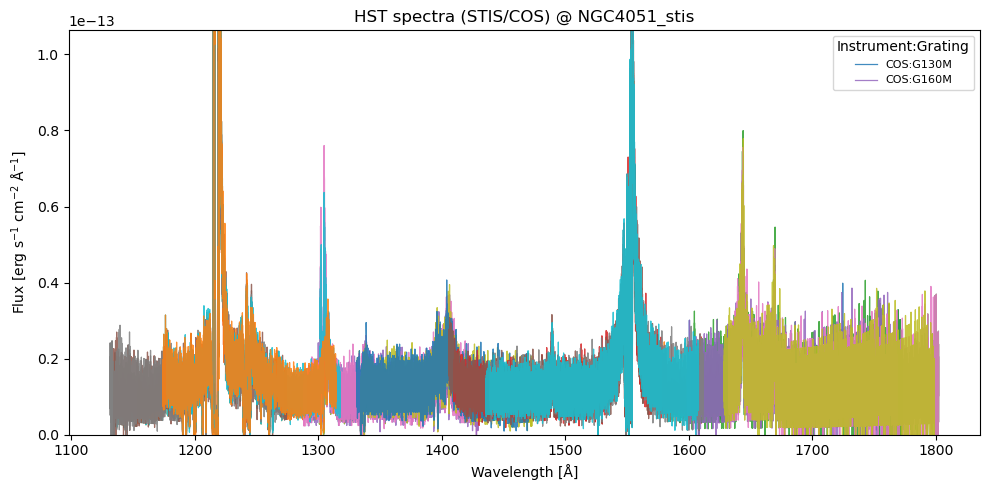

Stitched spectrum saved to: NGC4051_stis.fits
Grid: 13415 bins from 1131.4–1802.1 Å, dw=0.050 Å
Processing target: NGC4151
INFO: Found cached file hst_uv_dl/mastDownload/HST/o42302070/o42302070_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/o42302080/o42302080_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/o42302090/o42302090_x1d.fits with expected size 187200. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/o423020a0/o423020a0_x1d.fits with expected size 187200. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/o42303050/o42303050_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/o42303060/o42303060_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/o42303070/o42303070_sx1.fits with expected size 80640. [astroquery.query]


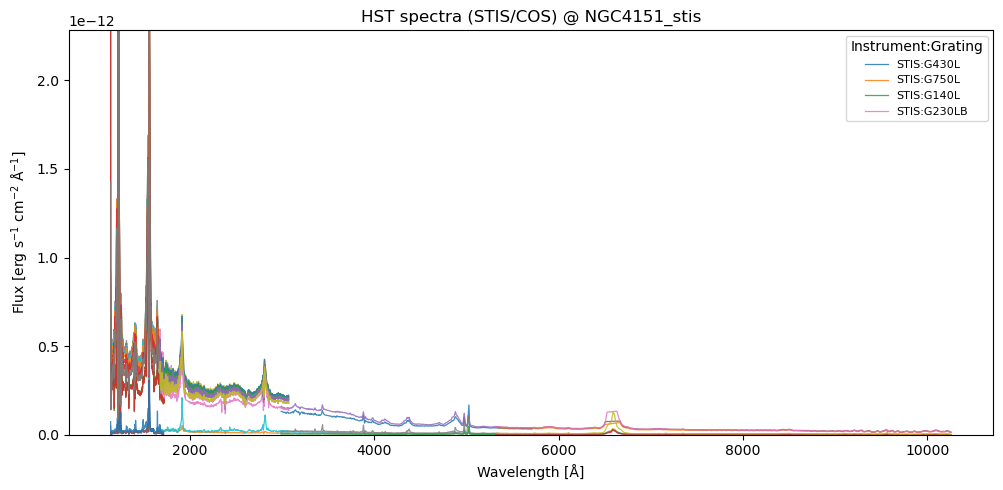

Stitched spectrum saved to: NGC4151_stis.fits
Grid: 6638 bins from 1138.3–10260.7 Å, dw=1.374 Å
Processing target: NGC4395
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu20010/lbgu20010_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu20020/lbgu20020_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu20030/lbgu20030_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu20040/lbgu20040_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu20050/lbgu20050_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu20060/lbgu20060_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu20070/lbgu20070_x1dsum.fits with expected 

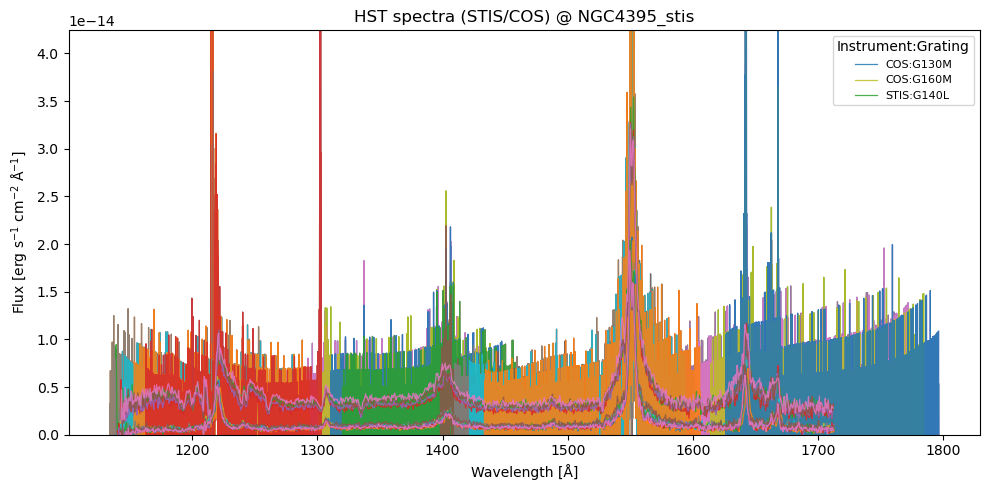

Stitched spectrum saved to: NGC4395_stis.fits
Grid: 13240 bins from 1134.3–1796.2 Å, dw=0.050 Å
Processing target: NGC3227
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb9n01010/lb9n01010_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb9n01020/lb9n01020_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb9n01030/lb9n01030_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb9n01040/lb9n01040_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb9n01050/lb9n01050_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb9n01060/lb9n01060_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lb9n01coq/lb9n01coq_x1d.fits with expected siz

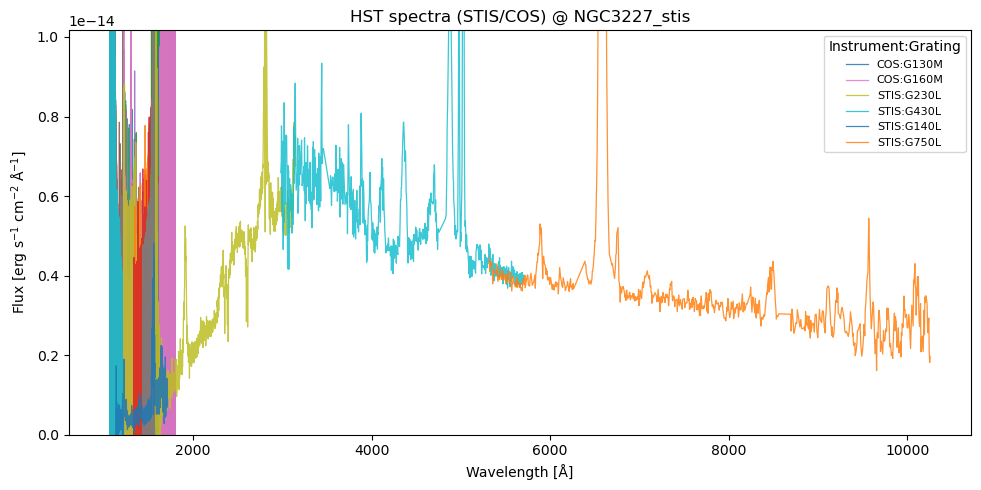

Stitched spectrum saved to: NGC3227_stis.fits
Grid: 183800 bins from 1065.4–10255.3 Å, dw=0.050 Å
Processing target: UCG06728


No HST spectroscopic observations (STIS/COS) found near that position.
Processing target: NGC4593
INFO: Found cached file hst_uv_dl/mastDownload/HST/ocuw01010/ocuw01010_x1d.fits with expected size 77760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ocuw01020/ocuw01020_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ocuw01030/ocuw01030_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ocuw02010/ocuw02010_x1d.fits with expected size 77760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ocuw02020/ocuw02020_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ocuw02030/ocuw02030_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ocuw03010/ocuw03010_x1d.fits with expected size 77760. [astroquery.query]
INFO: Found cached file hst

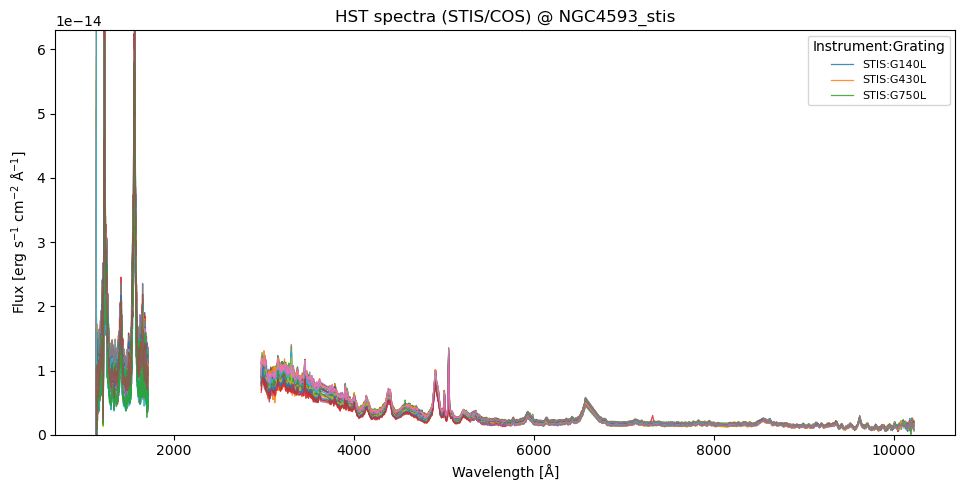

Stitched spectrum saved to: NGC4593_stis.fits
Grid: 3308 bins from 1138.0–10225.6 Å, dw=2.748 Å
Processing target: LEDA 90334


No HST spectroscopic observations (STIS/COS) found near that position.
Processing target: UCG 03478
No HST spectroscopic observations (STIS/COS) found near that position.
Processing target: NGC 3516
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu18020/lbgu18020_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu18060/lbgu18060_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu18djq/lbgu18djq_x1d.fits with expected size 3389760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu18dzq/lbgu18dzq_x1d.fits with expected size 3389760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu58010/lbgu58010_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/lbgu58020/lbgu58020_x1dsum.fits with expected size 1944000. [astroquery.query]
INFO: Found cached file hst

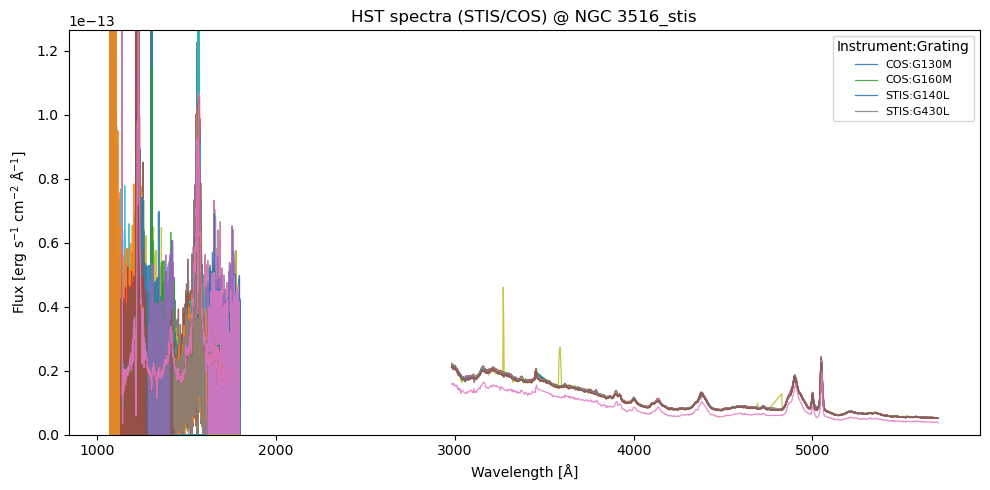

Stitched spectrum saved to: NGC 3516_stis.fits
Grid: 92725 bins from 1070.2–5706.4 Å, dw=0.050 Å
Processing target: NGC 4253
INFO: Found cached file hst_uv_dl/mastDownload/HST/o5l502020/o5l502020_x1d.fits with expected size 77760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/o5l502030/o5l502030_x1d.fits with expected size 77760. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ob1101010/ob1101010_sx1.fits with expected size 80640. [astroquery.query]
INFO: Found cached file hst_uv_dl/mastDownload/HST/ob1102010/ob1102010_sx1.fits with expected size 80640. [astroquery.query]


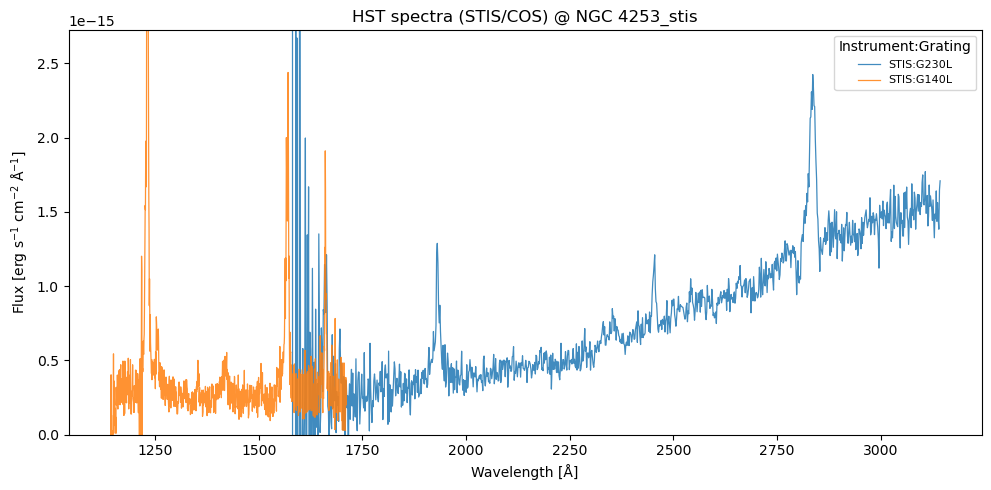

Stitched spectrum saved to: NGC 4253_stis.fits
Grid: 1880 bins from 1141.3–3143.7 Å, dw=1.066 Å


In [50]:
from astropy.coordinates import SkyCoord as SkCoord
for target in ['NGC4051', 'NGC4151', 'NGC4395', 'NGC3227', 'UCG06728', 'NGC4593', 'LEDA 90334', 'UCG 03478', 'NGC 3516', 'NGC 4253']:
    print(f"Processing target: {target}")
    fetch_plot_and_stitch_hst(SkCoord.from_name(target), save_basename=f"{target}_stis")

In [51]:
import numpy as np
N_ceph = 4
N_SBF = 2
sigma_int = 0.6
sigma_SBF = 0.2
sigma_ceph = 0.1
np.log(10)/5 * (N_ceph/(sigma_int**2 + sigma_ceph**2) + N_SBF/(sigma_int**2 + sigma_SBF**2))**(-1/2)

np.float64(0.11581601385743549)

In [45]:
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import os
from pathlib import Path

PREFERRED_PATTERNS = ("_drc.fits", "_drz.fits", "_i2d.fits", "_flc.fits", "_flt.fits")

def _lower(arr):
    return np.char.lower(np.asarray(arr).astype(str))

def _contains(arr, needle_lower):
    # returns boolean array: substring containment (case-insensitive)
    return np.char.find(_lower(arr), needle_lower) >= 0

def search_hst_imaging(
    coord,
    radius_arcsec=20,
    instruments=("WFC3/UVIS","WFC3/IR","ACS/WFC","ACS/HRC"),
    filters=None,
    min_calib_level=2,
    only_science=True,
    show=25,
    proposal_ids=None,     # NEW: optional whitelist like (15877, 13647)
):
    c = coord
    obs = Observations.query_region(coordinates=c, radius=radius_arcsec*u.arcsec)

    # --- Strict imaging filters
    if "obs_collection" in obs.colnames:
        obs = obs[_lower(obs["obs_collection"]) == "hst"]
    if "dataproduct_type" in obs.colnames:
        obs = obs[_lower(obs["dataproduct_type"]) == "image"]
    if only_science and "intentType" in obs.colnames:
        obs = obs[_contains(obs["intentType"], "science")]
    if instruments and "instrument_name" in obs.colnames:
        obs = obs[np.isin(obs["instrument_name"], instruments)]
    if (min_calib_level is not None) and ("calib_level" in obs.colnames):
        obs = obs[obs["calib_level"] >= min_calib_level]
    if proposal_ids is not None and "proposal_id" in obs.colnames:
        obs = obs[np.isin(obs["proposal_id"], list(proposal_ids))]
    if filters and "filters" in obs.colnames:
        fset = {f.upper() for f in filters}
        filt_vals = np.asarray(obs["filters"]).astype(str)
        keep = np.array([any(f in s.upper() for f in fset) for s in filt_vals])
        obs = obs[keep]

    if len(obs) == 0:
        return pd.DataFrame(), pd.DataFrame()

    # --- IMPORTANT: include timing columns so cadence works
    keep_cols = [
        "obsid","target_name","instrument_name","filters","t_exptime",
        "proposal_id","proposal_pi","obs_id","s_ra","s_dec","calib_level",
        "t_min","t_max","t_start"  # NEW
    ]
    df = obs.to_pandas()[[c for c in keep_cols if c in obs.colnames]].copy()

    sort_cols = [c for c in ["instrument_name","filters","t_exptime"] if c in df.columns]
    if sort_cols:
        df.sort_values(by=sort_cols, ascending=[True, True, False][:len(sort_cols)], inplace=True)

    # Products (unchanged)
    prod = Observations.get_product_list(obs)
    pdf = prod.to_pandas()
    def _best_rank(name):
        name = str(name).lower()
        for i, pat in enumerate(PREFERRED_PATTERNS):
            if name.endswith(pat):
                return i
        return 999
    if len(pdf):
        pdf["rank"] = pdf["productFilename"].apply(_best_rank)
        pdf.sort_values(["obsID","rank"], inplace=True)
        best = pdf.groupby("obsID", as_index=False).first()
        best_cols = ["obsID","productFilename","productURL","productSubGroupDescription",
                     "instrument_name","filters","size","rank","mtFlag"]
        best_view = best[[c for c in best_cols if c in best.columns]].copy()
    else:
        best_view = pd.DataFrame()

    # Return full df (no head()) so cadence has all rows
    return df, best_view

def download_hst_imaging(best_view, download_dir="hst_dl"):
    """
    Download the files listed in 'best_view' (as returned by search_hst_imaging).
    Returns a list of local file paths.
    """
    if len(best_view) == 0:
        return []

    # Re-query products for these obsIDs to pass to download_products
    obsids = best_view["obsID"].tolist()
    products = Observations.get_product_list(obsids)
    # Filter back down to the chosen filenames
    wanted = products[products["productFilename"].isin(best_view["productFilename"].tolist())]

    Path(download_dir).mkdir(parents=True, exist_ok=True)
    manifest = Observations.download_products(
        wanted,
        download_dir=download_dir,
        mrp_only=False
    )
    # Local file paths column name may vary with astroquery versions
    mdf = manifest.to_pandas()
    path_col = "Local Path" if "Local Path" in mdf.columns else "LocalPath"
    return mdf[path_col].dropna().tolist()

In [48]:
import numpy as np
import pandas as pd

# ---- Tunables ----
V_LIKE = {"F555W", "F606W", "F350LP"}
I_LIKE = {"F814W"}
H_LIKE = {"F160W"}

NEED_V = 3     # epochs
NEED_I_OPT = 3  # epochs for optical path
NEED_I_NIR = 3  # epochs for NIR+templates path
NEED_BASELINE_DAYS = 60.0

def _to_df(obs_or_df):
    """Accept astropy Table or pandas DataFrame."""
    if hasattr(obs_or_df, "colnames"):
        return obs_or_df.to_pandas()
    return obs_or_df.copy()

def _split_filters(val):
    """Normalize the 'filters' field into atomic filter names."""
    s = str(val).upper().replace(";", ",").replace("/", ",")
    toks = [t.strip() for t in s.split(",") if t.strip()]
    # If MAST gives combos like 'F555W+F814W', split those too:
    split_more = []
    for t in toks:
        split_more.extend([x for x in t.replace("+", ",").split(",") if x])
    return set(split_more) if split_more else set(toks)

def _unique_mjd_days(series):
    """Distinct observing days from MJD-like floats (t_min / t_start)."""
    arr = pd.to_numeric(series, errors="coerce").dropna().values
    return np.unique(np.floor(arr)).size

def summarize_epochs_and_baseline(obs_table_or_df):
    """
    Returns:
      - per_filter: DataFrame with columns [filter, n_epochs, t_baseline_days]
      - totals: dict with nV, nI, nH, baseline_days, baseline_known
    """
    df = _to_df(obs_table_or_df)
    if df.empty:
        return pd.DataFrame(), dict(nV=0, nI=0, nH=0, baseline_days=np.nan, baseline_known=False)

    # Build a row-per-visit view with an atomic filter label
    if "filters" not in df.columns:
        return pd.DataFrame(), dict(nV=0, nI=0, nH=0, baseline_days=np.nan, baseline_known=False)

    # Choose a time column for epoch counting; prefer t_min
    date_col = "t_min" if "t_min" in df.columns else ("t_start" if "t_start" in df.columns else None)

    rows = []
    for _, r in df.iterrows():
        fset = _split_filters(r["filters"])
        if not fset:
            continue
        for f in fset:
            rows.append({
                "filter": f,
                "t_min": r["t_min"] if "t_min" in df.columns else np.nan,
                "t_max": r["t_max"] if "t_max" in df.columns else np.nan,
                "t_start": r["t_start"] if "t_start" in df.columns else np.nan,
            })
    if not rows:
        return pd.DataFrame(), dict(nV=0, nI=0, nH=0, baseline_days=np.nan, baseline_known=False)

    visits = pd.DataFrame(rows)

    # Epochs per atomic filter (distinct days)
    per_filter = []
    for f in sorted(visits["filter"].unique()):
        sub = visits[visits["filter"] == f]
        if date_col:
            n_epochs = _unique_mjd_days(sub[date_col])
        else:
            # fall back to counting rows (crude)
            n_epochs = len(sub)
        # time span per filter if both t_min and t_max exist
        if {"t_min", "t_max"} <= set(visits.columns):
            tspan = float(np.nanmax(sub["t_max"]) - np.nanmin(sub["t_min"]))
        else:
            tspan = np.nan
        per_filter.append({"filter": f, "n_epochs": int(n_epochs), "t_baseline_days": tspan})
    per_filter = pd.DataFrame(per_filter).sort_values("filter").reset_index(drop=True)

    # Totals across families
    nV = per_filter[per_filter["filter"].isin(V_LIKE)]["n_epochs"].sum()
    nI = per_filter[per_filter["filter"].isin(I_LIKE)]["n_epochs"].sum()
    nH = per_filter[per_filter["filter"].isin(H_LIKE)]["n_epochs"].sum()

    # Overall baseline across all imaging (not just one filter)
    if {"t_min", "t_max"} <= set(visits.columns):
        baseline_days = float(np.nanmax(visits["t_max"]) - np.nanmin(visits["t_min"]))
        baseline_known = True
    else:
        baseline_days = np.nan
        baseline_known = False

    totals = dict(nV=int(nV), nI=int(nI), nH=int(nH),
                  baseline_days=baseline_days, baseline_known=baseline_known)
    return per_filter, totals

def assess_bands_and_cadence(obs_table_or_df, need_v=NEED_V, need_i_opt=NEED_I_OPT,
                             need_i_nir=NEED_I_NIR, need_baseline_days=NEED_BASELINE_DAYS):
    """
    Returns a compact dict with YES/NO for each path and a short reason list.
    """
    per_filter, totals = summarize_epochs_and_baseline(obs_table_or_df)
    if per_filter.empty:
        return {"ok_optical": False, "ok_nir_templates": False, "why": ["No filter metadata found."], "per_filter": per_filter, "totals": totals}

    nV, nI, nH = totals["nV"], totals["nI"], totals["nH"]
    base, known = totals["baseline_days"], totals["baseline_known"]

    # Decide; allow unknown baseline to pass if you set this to True
    require_baseline = True
    baseline_ok = (not require_baseline and not known) or (known and base >= need_baseline_days)

    ok_optical = (nV >= need_v) and (nI >= need_i_opt) and baseline_ok
    ok_nir     = (nH >= 1) and (nV >= need_v) and (nI >= need_i_nir) and baseline_ok

    why = []
    if not ok_optical:
        if nV < need_v:        why.append(f"Optical: need ≥{need_v} V-like epochs; have {nV}.")
        if nI < need_i_opt:    why.append(f"Optical: need ≥{need_i_opt} F814W epochs; have {nI}.")
        if require_baseline and known and base < need_baseline_days:
            why.append(f"Optical: baseline {base:.1f} d < {need_baseline_days} d.")
        if require_baseline and not known:
            why.append("Optical: baseline unknown (no t_min/t_max).")

    if not ok_nir:
        if nH < 1:             why.append("NIR: need ≥1 F160W epoch.")
        if nV < need_v:        why.append(f"NIR: need ≥{need_v} V-like epochs; have {nV}.")
        if nI < need_i_nir:    why.append(f"NIR: need ≥{need_i_nir} F814W epochs; have {nI}.")
        if require_baseline and known and base < need_baseline_days:
            why.append(f"NIR: baseline {base:.1f} d < {need_baseline_days} d.")
        if require_baseline and not known:
            why.append("NIR: baseline unknown (no t_min/t_max).")

    return {
        "ok_optical": ok_optical,
        "ok_nir_templates": ok_nir,
        "why": why,
        "per_filter": per_filter,
        "totals": totals
    }


In [49]:
from astropy.coordinates import SkyCoord as SkCoord
for target in ['NGC4051', 'NGC4151', 'NGC4395', 'NGC3227', 'UCG06728', 'NGC4593', 'LEDA 90334', 'UCG 03478', 'NGC 3516', 'NGC 4253']:
    print(f"Processing target: {target}")
    df_obs, df_best = search_hst_imaging(SkCoord.from_name(target))
    per_filter, totals = summarize_epochs_and_baseline(df_obs)      # or (summary)
    print(per_filter.to_string(index=False))
    print(totals)

    report = assess_bands_and_cadence(df_obs)                       # or (summary)
    print(report["ok_optical"], report["ok_nir_templates"])
    for w in report["why"]:
        print("-", w)

Processing target: NGC4051
   filter  n_epochs  t_baseline_days
DETECTION        18      5559.564029
    F160W         6        72.931054
    F275W         1         0.214259
    F336W         1         0.101829
   F350LP        12        72.888416
    F487N         1         0.012696
    F502N         1         0.048102
    F547M         2       355.354661
    F550M         1         0.014702
    F555W         3        37.598856
    F645N         1         0.034225
    F673N         1         0.012697
    F814W         4       498.736936
{'nV': 15, 'nI': 4, 'nH': 6, 'baseline_days': 5559.564029139998, 'baseline_known': True}
True True
Processing target: NGC4151
   filter  n_epochs  t_baseline_days
  CLEAR2L         1         0.010671
DETECTION        16      6540.929275
    F160W         7      1725.092681
   F350LP        12        73.841101
    F547M         1         0.034282
    F550M         2       444.701586
    F555W         4      1818.146178
    F814W         4      1810.920